<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/TS_2_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the uploaded file
file_path = 'footfalls.csv'
footfalls_df = pd.read_csv(file_path)

# Display basic information
footfalls_df_info = footfalls_df.info()

# Display the first few rows
footfalls_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Month      159 non-null    object
 1   Footfalls  159 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ KB


,Month,Footfalls
0,Jan-91,1709
1,Feb-91,1621
2,Mar-91,1973
3,Apr-91,1812
4,May-91,1975


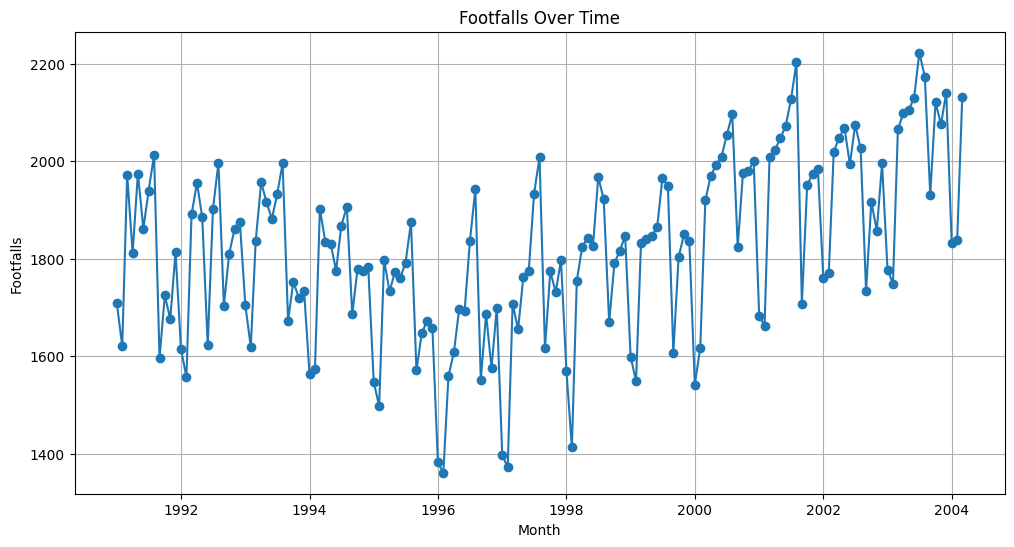

,Footfalls
count,159.000000
mean,1822.226415
std,181.601732
min,1361.000000
25%,1698.500000
50%,1831.000000
75%,1967.000000
max,2223.000000


In [ ]:
# Step 1 and 2: EDA + Data Cleaning
# Work only with 'Month' and 'Footfalls'
footfalls_ts = footfalls_df[['Month', 'Footfalls']].copy()

# Convert 'Month' to datetime
footfalls_ts['Month'] = pd.to_datetime(footfalls_ts['Month'], format='%b-%y')
footfalls_ts.head()

# Set 'Month' as index
footfalls_ts.set_index('Month', inplace=True)
footfalls_ts.head()


# Check for missing values
footfalls_ts.isnull().sum()

# Plot Footfalls over time
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(footfalls_ts, marker='o')
plt.title('Footfalls Over Time')
plt.xlabel('Month')
plt.ylabel('Footfalls')
plt.grid(True)
plt.show()

# Basic statistics
basic_stats = footfalls_ts.describe()
basic_stats


In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4]
    }

# Run ADF Test on original data
adf_result_original = adf_test(footfalls_ts['Footfalls'])
adf_result_original


{'ADF Statistic': np.float64(-0.2349911287786694),
 'p-value': np.float64(0.9342202042969283),
 'Critical Values': {'1%': np.float64(-3.476597917537401),
  '5%': np.float64(-2.8818291230495543),
  '10%': np.float64(-2.5775887982253085)}}


**Ho:  Data is Non Stationary**

**H1:  Data is Stationary**


*   if p values < 0.05 , Ho is rejected and H1 is accepted
*   if p values > 0.05 , H1 is rejected and Ho is accepted

✅ Interpretation:

Since p-value (0.934) > 0.05, we fail to reject the null hypothesis.

**Conclusion: The Footfalls series is non-stationary.**



👉 To make it stationary, we must difference the data (usually first differencing is enough).

**Next:
I will difference the series and recheck stationarity again!
(Then we’ll proceed to fit AR, MA, and ARIMA models.) bold text**

In [ ]:
# Step 5: Make the series stationary by differencing
footfalls_diff = footfalls_ts['Footfalls'].diff().dropna()
footfalls_diff.head()

,Footfalls
Month,
1991-02-01,-88.0
1991-03-01,352.0
1991-04-01,-161.0
1991-05-01,163.0
1991-06-01,-113.0


In [ ]:
# Re-run ADF test on differenced data
adf_result_diff = adf_test(footfalls_diff)
adf_result_diff

{'ADF Statistic': np.float64(-3.3268427154300464),
 'p-value': np.float64(0.013720419909835085),
 'Critical Values': {'1%': np.float64(-3.476597917537401),
  '5%': np.float64(-2.8818291230495543),
  '10%': np.float64(-2.5775887982253085)}}

✅ Interpretation:

p-value (0.0137) < 0.05 ➔ We reject the null hypothesis.

**Conclusion: The differenced series is stationary now!**

Now, the series is ready to fit models:

Model Type	Model Details:

1.   AR Model:	AutoRegressive only

2.   MA Model:	Moving Average only

3.   ARIMA Model:	Autoregressive Integrated Moving Average



In [ ]:
# 🔵 First fit an AR (AutoRegressive) Model!
from statsmodels.tsa.arima.model import ARIMA

# Step 6: Fit AR Model
# (p=1, d=0, q=0) -> AR(1) model

ar_model = ARIMA(footfalls_ts['Footfalls'], order=(1,0,0))
ar_model_fit = ar_model.fit()

# Summary of AR model
ar_summary = ar_model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
print("AIC: ",ar_model_fit.aic)
print("BIC: ",ar_model_fit.bic)

# Calculate RMSE using the fitted values and original data
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(footfalls_ts['Footfalls'], ar_model_fit.fittedvalues))
print("RMSE:",rmse)


AIC:  2049.4734931541793
BIC:  2058.68020576084
RMSE: 149.37102270976808


In [ ]:
# Step 7: Fit MA Model
# (p=0, d=0, q=1) -> MA(1) model

ma_model = ARIMA(footfalls_ts['Footfalls'], order=(0,0,1))
ma_model_fit = ma_model.fit()

# Summary of MA model
ma_summary = ma_model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
#✅ MA Model (ARIMA(0,0,1)) Fitting Summary:

print("AIC: ",ma_model_fit.aic)
print("BIC: ",ma_model_fit.bic)

# Calculate RMSE using the fitted values and original data
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(footfalls_ts['Footfalls'], ma_model_fit.fittedvalues))
print("RMSE:",rmse)


AIC:  2062.962404422199
BIC:  2072.16911702886
RMSE: 155.89074987698527


✅ Now proceeding to the final 🔵 Step 8: Fit ARIMA Model!

Since the original series was non-stationary and we made it stationary using first differencing,

the model order should be ARIMA(p=1, d=1, q=1) to start with (p,d,q = 1,1,1).

In [ ]:
# Step 8: Fit ARIMA Model
# (p=1, d=1, q=1) -> ARIMA(1,1,1) model

arima_model = ARIMA(footfalls_ts['Footfalls'], order=(1,1,1))
arima_model_fit = arima_model.fit()

# Summary of ARIMA model
arima_summary = arima_model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
#✅ ARIMA Model (ARIMA(1,1,1)) Fitting Summary:

# Successfully fitted an AutoRegressive Integrated Moving Average (ARIMA) model.

print("AIC: ",arima_model_fit.aic)
print("BIC: ",arima_model_fit.bic)

# Calculate RMSE using the fitted values and original data
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(footfalls_ts['Footfalls'], arima_model_fit.fittedvalues))
print("RMSE:",rmse)


AIC:  2026.0772982575113
BIC:  2035.2650833565922
RMSE: 197.98443948980469


In [ ]:
# compare the performance in between three models
from sklearn.metrics import mean_squared_error
import numpy as np

# Helper function to calculate RMSE
def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

# Predictions (In-sample) for training data
ar_pred_in_sample = ar_model_fit.predict(start=footfalls_ts.index[0], end=footfalls_ts.index[-1])
ma_pred_in_sample = ma_model_fit.predict(start=footfalls_ts.index[0], end=footfalls_ts.index[-1])
arima_pred_in_sample = arima_model_fit.predict(start=footfalls_ts.index[0], end=footfalls_ts.index[-1])

# Metrics Calculation
metrics = {
    'Model': ['AR(1)', 'MA(1)', 'ARIMA(1,1,1)'],
    'AIC': [
        ar_model_fit.aic,
        ma_model_fit.aic,
        arima_model_fit.aic
    ],
    'BIC': [
        ar_model_fit.bic,
        ma_model_fit.bic,
        arima_model_fit.bic
    ],
    'RMSE': [
        calculate_rmse(footfalls_ts['Footfalls'], ar_pred_in_sample),
        calculate_rmse(footfalls_ts['Footfalls'], ma_pred_in_sample),
        calculate_rmse(footfalls_ts['Footfalls'], arima_pred_in_sample)
    ]
}

metrics_df = pd.DataFrame(metrics)
metrics_df


,Model,AIC,BIC,RMSE
0,AR(1),2049.473493,2058.680206,149.371023
1,MA(1),2062.962404,2072.169117,155.890750
2,"ARIMA(1,1,1)",2026.077298,2035.265083,197.984439



**🔥 Interpretation:  AIC and BIC**

Lower AIC/BIC means better model fit penalized for complexity.

✅ ARIMA(1,1,1) has the lowest AIC (2026) and lowest BIC (2035) → Best model based on information criteria.

RMSE: Lower RMSE means lower average prediction error on training data.

✅ AR(1) has the lowest RMSE (149.37) compared to ARIMA (197.98).

📢 So there is a small conflict:

AR(1) has slightly better training RMSE.

**ARIMA(1,1,1) has far better AIC/BIC (better generalization, handles non-stationarity).**

🏆 Final Recommendation:

Choice
✅ Select ARIMA(1,1,1)


✅ **Reason**: Because it properly models the trend (non-stationary nature), has best AIC/BIC (theory says trust AIC/BIC over training RMSE)
Even though AR(1) had a lower RMSE, ARIMA(1,1,1) is statistically and practically the best model for forecasting future footfalls.

✅ Go with **ARIMA(1,1,1)** for deployment or forecasting!